In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def set_style():
    mpl.rcParams.update({
        # Figure / export
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,   # editable text in Illustrator
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # Typography
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,

        # Axes look
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,

        # Lines
        "lines.linewidth": 1.2,
    })
set_jmlr_style()

<function __main__.set_jmlr_style()>

In [20]:
import pandas as pd
import gpboost as gpb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# The HSB dataset is available through Rdatasets
url = "https://vincentarelbundock.github.io/Rdatasets/csv/mlmRev/Hsb82.csv"
hsb = pd.read_csv(url)

# Basic exploration
print(hsb.head())
print(hsb.columns)
print(hsb.groupby('school').size().describe())  # Group sizes

   rownames  school minrty      sx    ses    mAch   meanses  sector      cses
0         1    1224     No  Female -1.528   5.876 -0.434383  Public -1.093617
1         2    1224     No  Female -0.588  19.708 -0.434383  Public -0.153617
2         3    1224     No    Male -0.528  20.349 -0.434383  Public -0.093617
3         4    1224     No    Male -0.668   8.781 -0.434383  Public -0.233617
4         5    1224     No    Male -0.158  17.898 -0.434383  Public  0.276383
Index(['rownames', 'school', 'minrty', 'sx', 'ses', 'mAch', 'meanses',
       'sector', 'cses'],
      dtype='object')
count    160.000000
mean      44.906250
std       11.854886
min       14.000000
25%       35.000000
50%       47.000000
75%       54.000000
max       67.000000
dtype: float64


In [21]:
Y = hsb["mAch"]
X = hsb["ses"] # add sex, minorty and sector for more complexity
Z = hsb["school"]

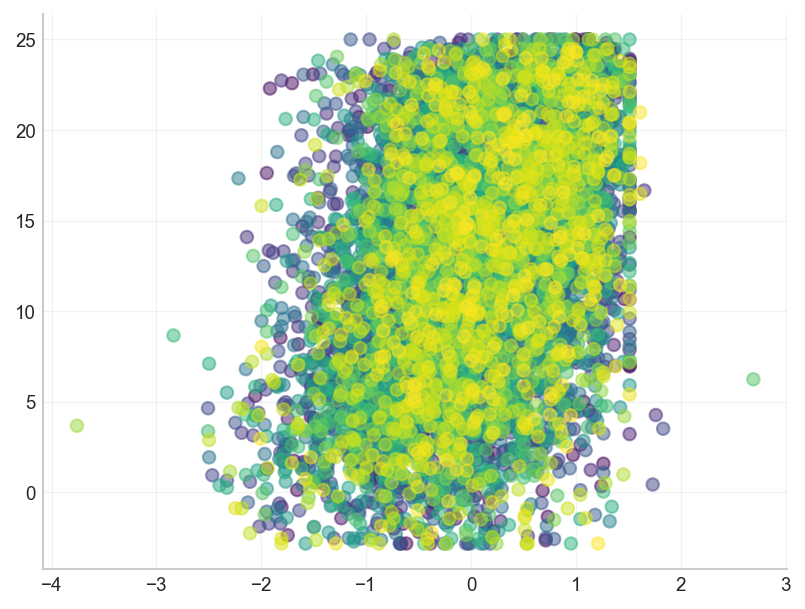

In [22]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.scatter(X, Y, alpha=0.5, cmap='viridis', c = Z)

In [23]:
tau = 0.05

gpq = gpb.GPModel(
    group_data=Z,
    group_rand_coef_data=X,
    ind_effect_group_rand_coef=[1],
    likelihood="asymmetric_laplace",
    likelihood_additional_param=tau,
    matrix_inversion_method = "cholesky",
    num_parallel_threads=2,
    )

params = {
    "estimate_aux_pars": True,
    "init_aux_pars": np.array([0.1]),
    #"init_cov_pars": np.array([1,1]),
    "trace": True,
    }

gpq.fit(X=X, y=Y, params=params)

[GPBoost] [Debug] The covariate data contains no column of ones, i.e., no intercept is included 
[GPBoost] [Debug] GPModel: initial parameters: 
[GPBoost] [Debug] cov_pars[0]: 0.5
[GPBoost] [Debug] cov_pars[1]: 0.5
[GPBoost] [Debug] beta[0]: 0
[GPBoost] [Debug] scale: 0.1
[GPBoost] [Debug] Initial approximate negative marginal log-likelihood: 48609.5
[GPBoost] [Debug] GPModel: parameters after optimization iteration number 1: 
[GPBoost] [Debug] cov_pars[0]: 0.519324
[GPBoost] [Debug] cov_pars[1]: 0.506326
[GPBoost] [Debug] beta[0]: 0.0143828
[GPBoost] [Debug] scale: 0.271594
[GPBoost] [Debug] Approximate negative marginal log-likelihood: 29409.6
[GPBoost] [Debug] GPModel: parameters after optimization iteration number 2: 
[GPBoost] [Debug] cov_pars[0]: 0.535697
[GPBoost] [Debug] cov_pars[1]: 0.509733
[GPBoost] [Debug] beta[0]: 0.0312169
[GPBoost] [Debug] scale: 0.38266
[GPBoost] [Debug] Approximate negative marginal log-likelihood: 27176.8
[GPBoost] [Debug] GPModel: parameters after op

In [24]:
gpq_median = gpb.GPModel(
    group_data=Z,
    group_rand_coef_data=X,
    ind_effect_group_rand_coef=[1],
    likelihood="asymmetric_laplace",
    likelihood_additional_param=0.5,
    matrix_inversion_method = "cholesky",
    num_parallel_threads=2,
    )

params = {
    "estimate_aux_pars": True,
    "init_aux_pars": np.array([0.1]),
    #"init_cov_pars": np.array([1,1]),
    "trace": True,
    }

gpq_median.fit(X=X, y=Y, params=params)

[GPBoost] [Debug] The covariate data contains no column of ones, i.e., no intercept is included 
[GPBoost] [Debug] GPModel: initial parameters: 
[GPBoost] [Debug] cov_pars[0]: 0.5
[GPBoost] [Debug] cov_pars[1]: 0.5
[GPBoost] [Debug] beta[0]: 0
[GPBoost] [Debug] scale: 0.1
[GPBoost] [Debug] Initial approximate negative marginal log-likelihood: 192826
[GPBoost] [Debug] GPModel: parameters after optimization iteration number 1: 
[GPBoost] [Debug] cov_pars[0]: 0.569201
[GPBoost] [Debug] cov_pars[1]: 0.503887
[GPBoost] [Debug] beta[0]: 0.00772889
[GPBoost] [Debug] scale: 0.269531
[GPBoost] [Debug] Approximate negative marginal log-likelihood: 85783.2
[GPBoost] [Debug] GPModel: parameters after optimization iteration number 2: 
[GPBoost] [Debug] cov_pars[0]: 0.688369
[GPBoost] [Debug] cov_pars[1]: 0.510628
[GPBoost] [Debug] beta[0]: 0.0195329
[GPBoost] [Debug] scale: 0.475517
[GPBoost] [Debug] Approximate negative marginal log-likelihood: 57235.8
[GPBoost] [Debug] GPModel: parameters after o

In [25]:
gpq.get_coef()
gpq.get_aux_pars()

,scale
Param.,0.581764


In [26]:
gpq.get_cov_pars()

,school,school_rand_coef_ses
Param.,14.311886,2.600982


In [27]:
gpq.predict_training_data_random_effects()

,school,school_rand_coef_ses
0,1.098219,-0.998197
1,1.098219,-0.998197
2,1.098219,-0.998197
3,1.098219,-0.998197
4,1.098219,-0.998197
...,...,...
7180,4.978670,-3.203678
7181,4.978670,-3.203678
7182,4.978670,-3.203678
7183,4.978670,-3.203678


In [28]:
y_tau = gpq.predict(X_pred = X, group_data_pred =Z, group_rand_coef_data_pred =X, predict_response=False)
y_median = gpq_median.predict(X_pred = X, group_data_pred =Z, group_rand_coef_data_pred =X, predict_response=False)

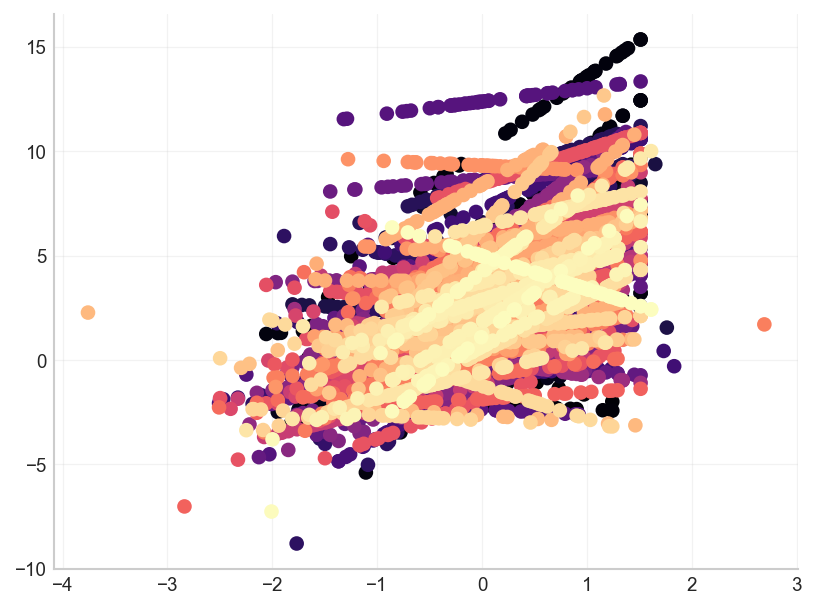

In [29]:
#plt.scatter(X, Y, alpha=0.5, cmap='viridis', c = Z)
#plt.xlabel("meanses")
plt.scatter(X, y_tau["mu"], c = Z, cmap = "magma")

In [30]:
#subset some schools
schools = Z.unique()[:10]
Z_subset = Z[Z.isin(schools)]
X_subset = X[Z.isin(schools)]
Y_subset = Y[Z.isin(schools)]
y_tau_subset = gpq.predict(X_pred = X_subset, group_data_pred =Z_subset, group_rand_coef_data_pred =X_subset, predict_response=False)
y_median_subset = gpq_median.predict(X_pred = X_subset, group_data_pred =Z_subset, group_rand_coef_data_pred =X_subset, predict_response=False)


In [31]:
#order
order = np.argsort(X_subset)

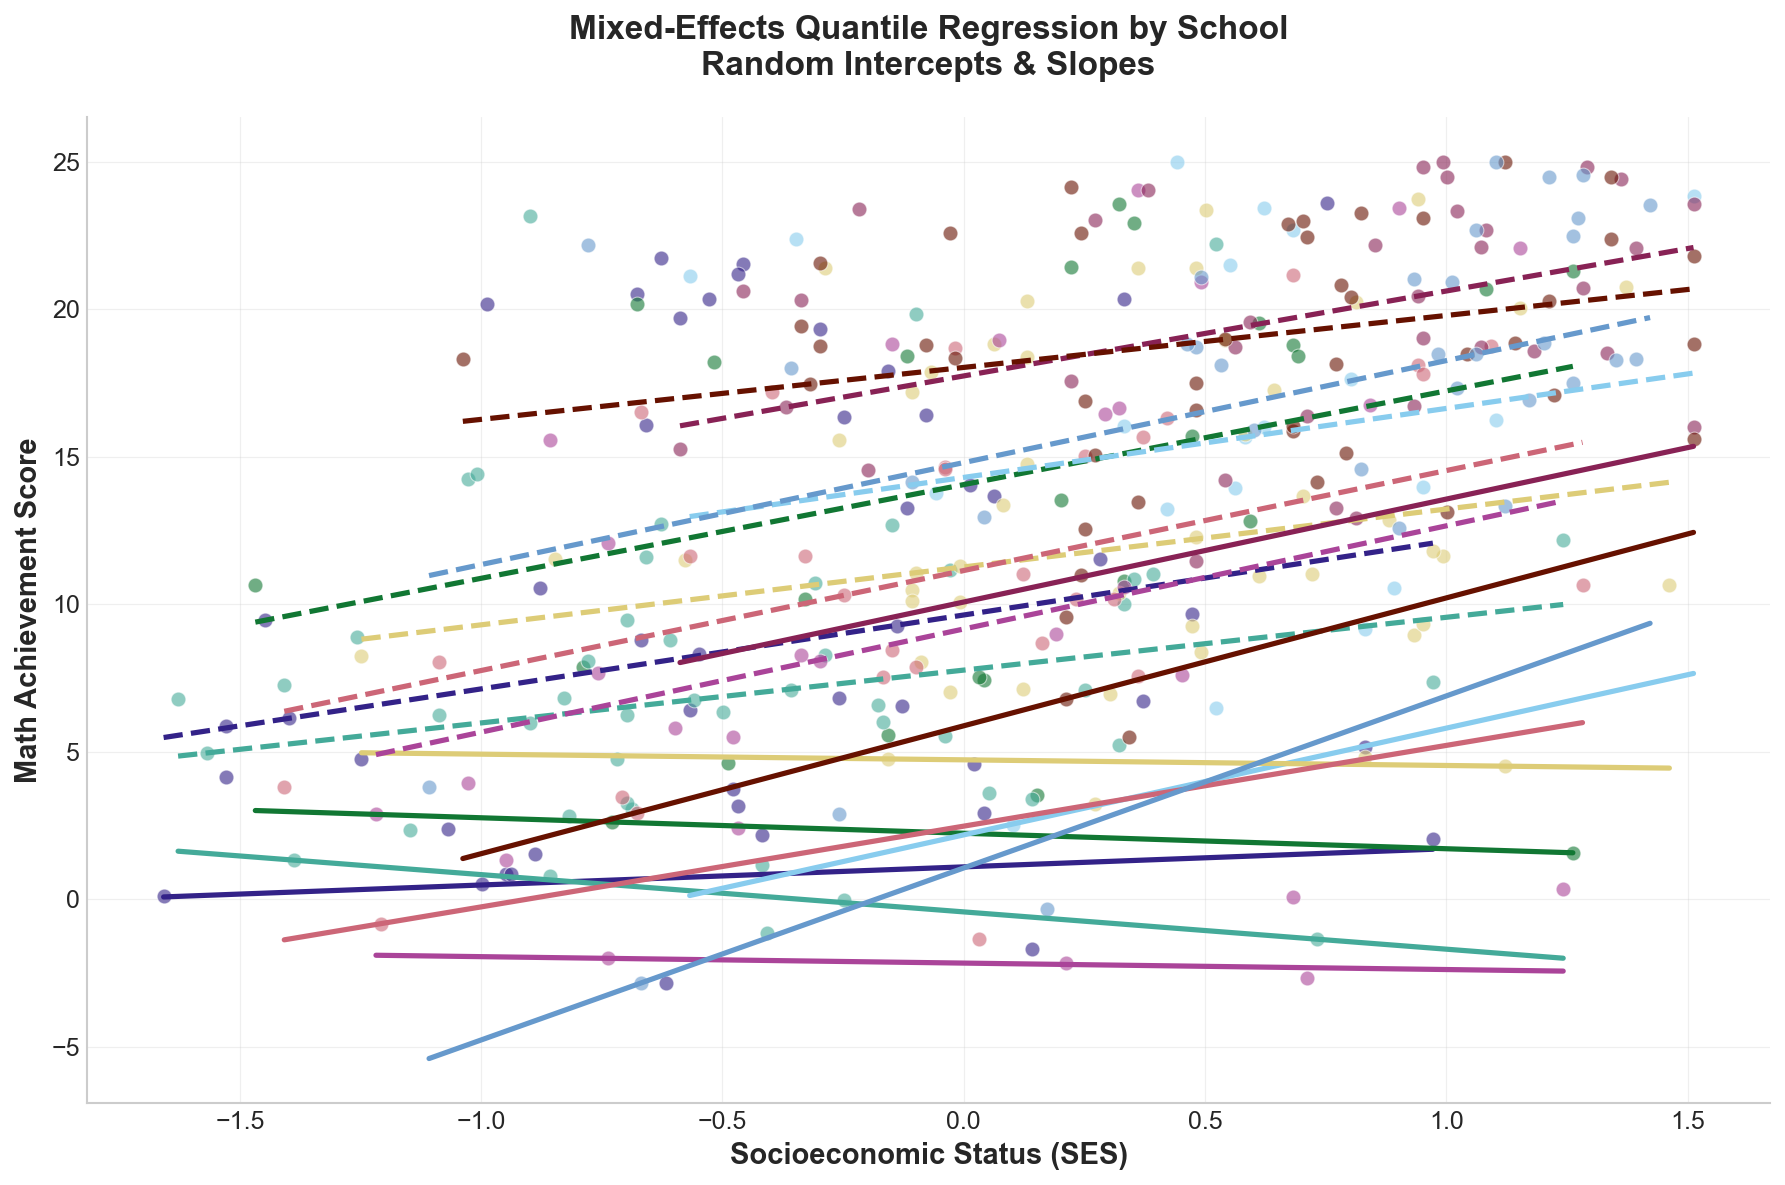

In [32]:
# Set better style and figure size
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 8))

# Get unique schools
unique_schools = np.unique(Z_subset)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_schools)))
colors = ['#332288', '#117733', '#44AA99', '#88CCEE', '#DDCC77', '#CC6677', 
          '#AA4499', '#882255', '#661100', '#6699CC', '#AA4466', '#4477AA']

for i, school_id in enumerate(unique_schools):
    # Get data for this school
    school_mask = (Z_subset == school_id)
    school_x = X_subset[school_mask].reset_index(drop=True)
    school_y_tau = y_tau_subset["mu"][school_mask]
    school_y_median = y_median_subset["mu"][school_mask]
    school_y_obs = Y_subset[school_mask].reset_index(drop=True)
    
    # Sort by x-values for smooth lines
    sort_idx = np.argsort(school_x)
    x_sorted = school_x[sort_idx]
    y_tau_sorted = school_y_tau[sort_idx]
    y_median_sorted = school_y_median[sort_idx]
    y_obs_sorted = school_y_obs[sort_idx]
    
    # Plot predicted line
    plt.plot(x_sorted, y_tau_sorted, 
             color=colors[i], linewidth=2.5, 
             label=f'School {int(school_id)}' if i < 8 else "")
    plt.plot(x_sorted, y_median_sorted, 
             color=colors[i], linewidth=2.5, linestyle='--', 
             label=f'School {int(school_id)}' if i < 8 else "")
    
    # Plot observed points
    plt.scatter(school_x, school_y_obs, 
               color=colors[i], alpha=0.6, s=50, 
               edgecolors='white', linewidths=0.5)

# Labels and styling
plt.xlabel('Socioeconomic Status (SES)', fontsize=14, fontweight='bold')
plt.ylabel('Math Achievement Score', fontsize=14, fontweight='bold')
plt.title('Mixed-Effects Quantile Regression by School\nRandom Intercepts & Slopes', 
          fontsize=16, fontweight='bold', pad=20)

# Legend and grid
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

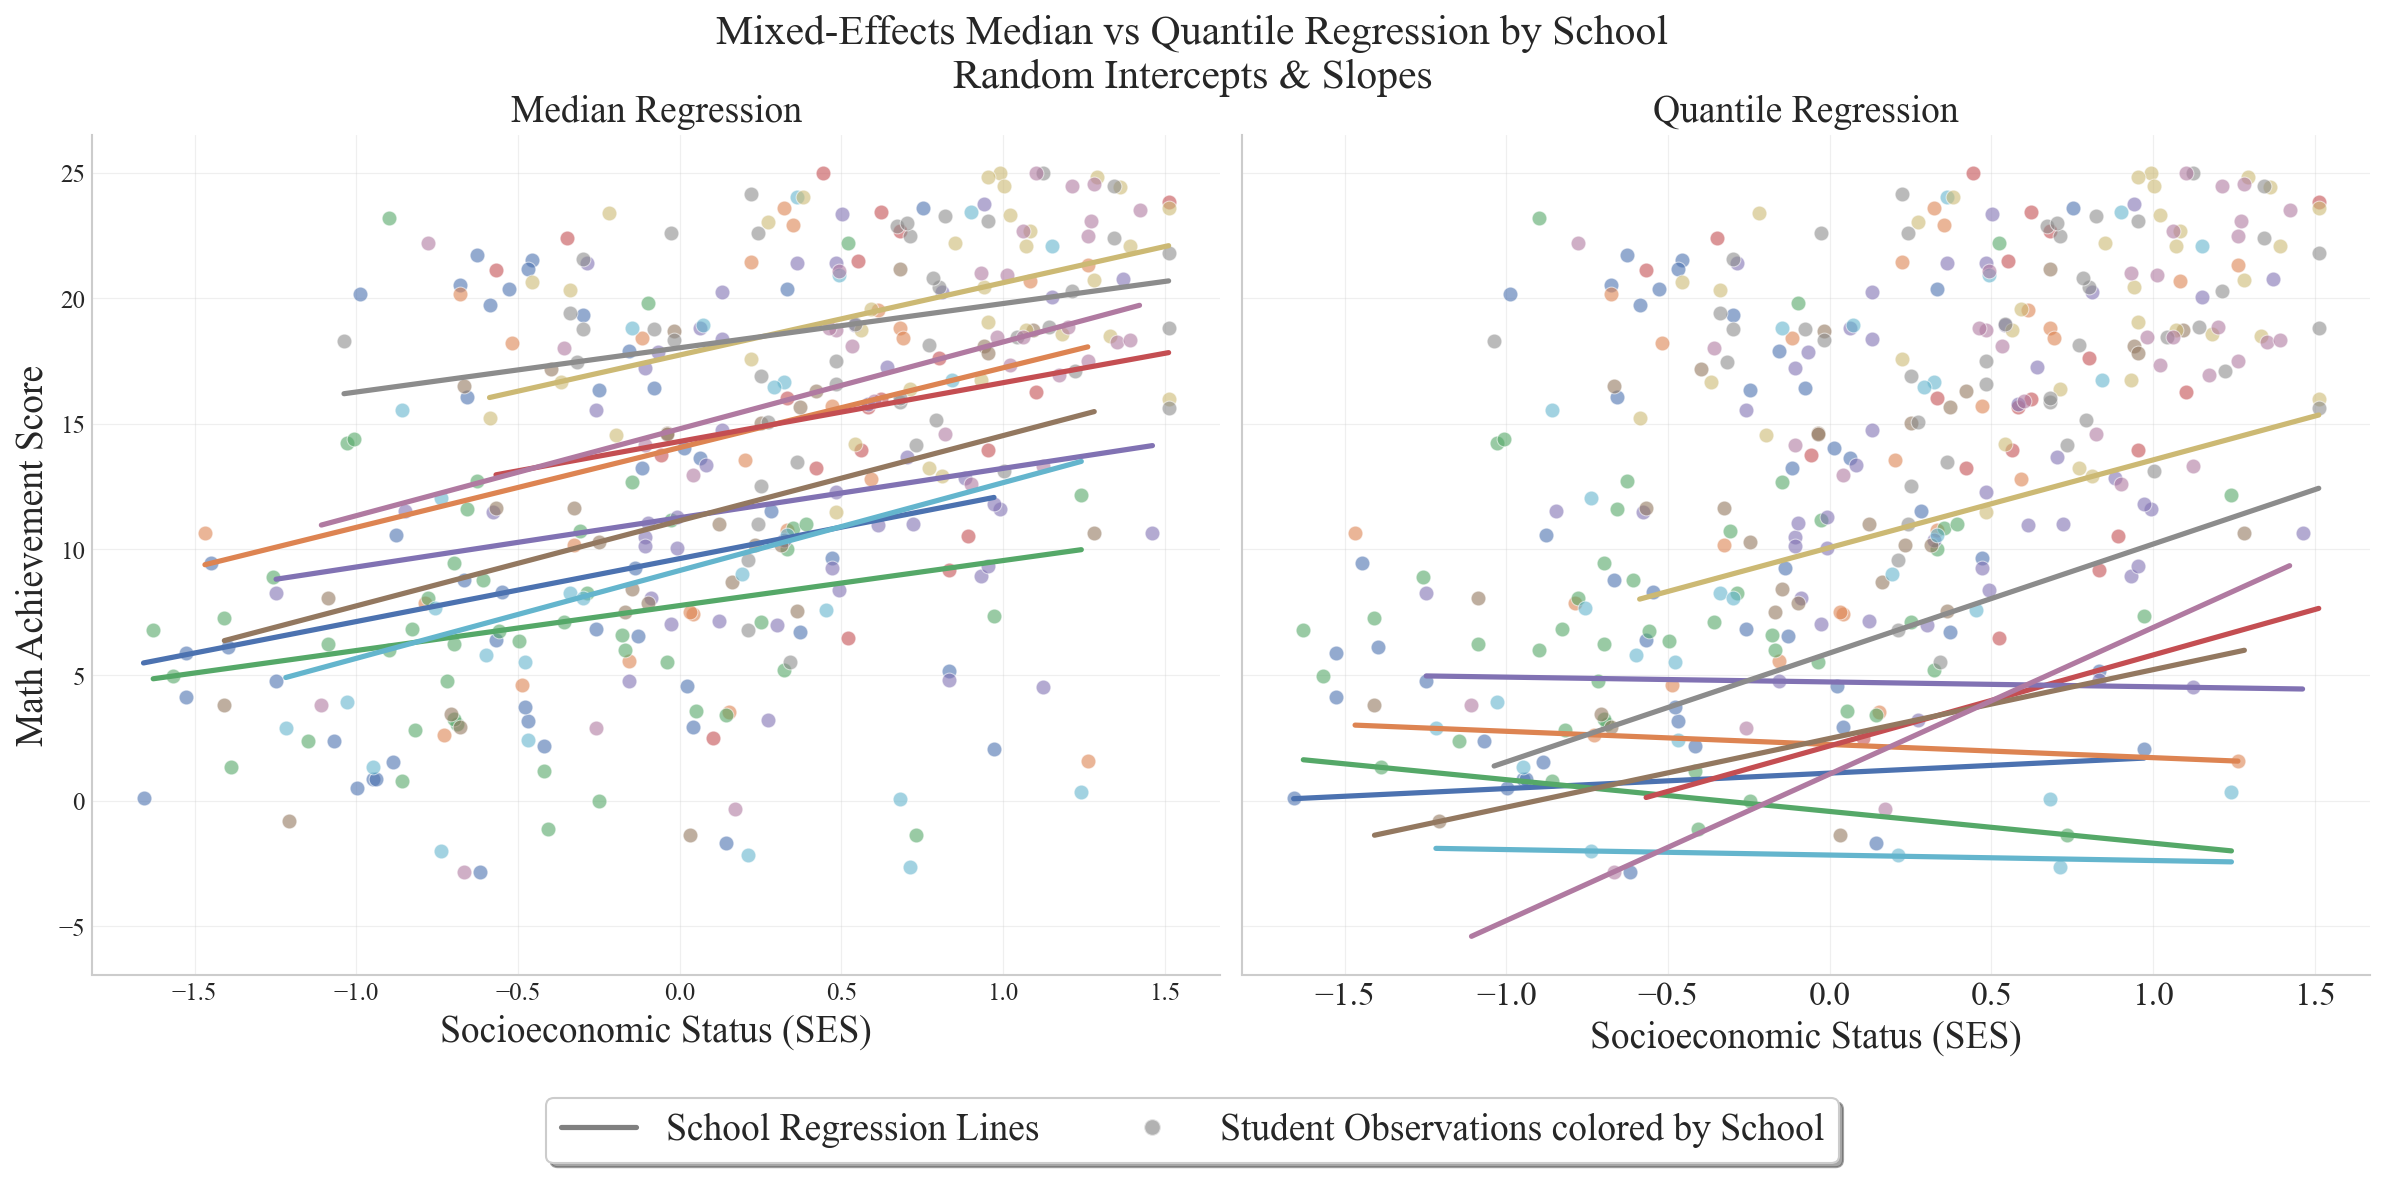

: 

In [ ]:
# Option 1: Side-by-side subplots with shared y-axis and unified styling
#plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Color palette
colors = ['#332288', '#117733', '#44AA99', '#88CCEE', '#DDCC77', '#CC6677', 
          '#AA4499', '#882255', '#661100', '#6699CC', '#AA4466', '#4477AA']
colors = [
    "#4C72B0",  # muted blue
    "#DD8452",  # muted orange
    "#55A868",  # muted green
    "#C44E52",  # muted red
    "#8172B3",  # muted purple
    "#937860",  # muted brown
    "#64B5CD",  # muted cyan
    "#CCB974",  # muted yellow / ochre
    "#8C8C8C",  # neutral gray
    "#B07AA1",  # muted pink
]

unique_schools = np.unique(Z_subset)
set_style()
# Left plot: Median fit
for i, school_id in enumerate(unique_schools):
    school_mask = (Z_subset == school_id)
    school_x = X_subset[school_mask].reset_index(drop=True)
    school_y_median = y_median_subset["mu"][school_mask]
    school_y_obs = Y_subset[school_mask].reset_index(drop=True)
    
    sort_idx = np.argsort(school_x)
    x_sorted = school_x[sort_idx]
    y_median_sorted = school_y_median[sort_idx]
    
    ax1.plot(x_sorted, y_median_sorted, color=colors[i], linewidth=2.5)
    ax1.scatter(school_x, school_y_obs, color=colors[i], alpha=0.6, s=50,
                edgecolors='white', linewidths=0.5)

ax1.set_xlabel('Socioeconomic Status (SES)', fontsize=18)#, fontweight='bold')
ax1.set_ylabel('Math Achievement Score', fontsize=18) #, fontweight='bold')
ax1.set_title('Median Regression', fontsize=18) #, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', labelsize=12)

# Right plot: Quantile fit
for i, school_id in enumerate(unique_schools):
    school_mask = (Z_subset == school_id)
    school_x = X_subset[school_mask].reset_index(drop=True)
    school_y_tau = y_tau_subset["mu"][school_mask]
    school_y_obs = Y_subset[school_mask].reset_index(drop=True)
    
    sort_idx = np.argsort(school_x)
    x_sorted = school_x[sort_idx]
    y_tau_sorted = school_y_tau[sort_idx]
    
    ax2.plot(x_sorted, y_tau_sorted, color=colors[i], linewidth=2.5)
    ax2.scatter(school_x, school_y_obs, color=colors[i], alpha=0.6, s=50,
                edgecolors='white', linewidths=0.5)

ax2.set_xlabel('Socioeconomic Status (SES)', fontsize=18)#, fontweight='bold')
ax2.set_title('Quantile Regression', fontsize=18) #, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', labelsize=16)

# Unified main title and simple legend
fig.suptitle('Mixed-Effects Median vs Quantile Regression by School\nRandom Intercepts & Slopes', 
             fontsize=20, y=0.95) # fontweight='bold'
 
# Simple legend explaining colors represent schools
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='gray', linewidth=2.5, label='School Regression Lines'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                          markersize=8, alpha=0.6, label='Student Observations colored by School')]

fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, 0.02), 
           ncol=2, fontsize=18, frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.15)
plt.show()
